# Simulating Country Interactions Based on Hungarian Data - Visualization
----

# Packages

In [1]:
import pypsa

In [2]:
from utils import tech_colors, week_numbers, seasons
from utils import plot_generator_t, plot_links

import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

# Create analyzed dates

In [3]:
dates = []
start_date = pd.to_datetime('2000-01-01')
for week in week_numbers.values():
    s = start_date + pd.Timedelta(weeks=week-1)
    e = s + pd.Timedelta(days=6, hours=23)
    dates.append(pd.date_range(start=s ,end=e, freq='h').to_list())

# Optimized data exploration


In [4]:
network = pypsa.Network("data/connected_power_network.nc")

INFO:pypsa.network.io:Imported network 'Connected Network' has buses, carriers, generators, links, loads, storage_units, sub_networks


In [5]:
gen_p_nom_opt = pd.DataFrame(network.generators.p_nom_opt.values.reshape(-1, 13),
                         index=network.buses.index.tolist(),
                         columns=list(tech_colors.keys())[:-2]
                        )
gen_p_nom_opt # optimal nominal power of generators

,Solar,Wind Onshore,Wind Offshore,Hydro Run-of-river,Hydro Water Reservoir,Geothermal,Biomass,Waste,Nuclear,Fusion,Fossil Lignite,Fossil Hard coal,Fossil Gas
country_0,1473.249503,-0.0,2000.0,36.0,28.0,-0.0,-0.0,300.0,-0.000000,-0.000000,-0.0,4000.0,-0.000000
country_1,2400.000000,500.0,-0.0,300.0,60.0,-0.0,-0.0,-0.0,900.000000,-0.000000,-0.0,60.0,1652.433571
country_2,1300.000000,500.0,60.0,200.0,20.0,1800.0,-0.0,-0.0,1092.806338,-0.000000,-0.0,80.0,251.850268
country_3,600.000000,10.0,1200.0,40.0,1400.0,1500.0,-0.0,-0.0,10.000000,268.214385,-0.0,800.0,-0.000000
country_4,-0.000000,300.0,-0.0,80.0,1800.0,-0.0,-0.0,100.0,-0.000000,-0.000000,-0.0,2100.0,-0.000000


In [6]:
trading_p_nom_opt = np.zeros((len(network.buses), len(network.buses)))
for item, value in network.links.p_nom_opt.items():
    trading_p_nom_opt[int(item.split('_')[1]), int(item.split('_')[2])] = value

trading_p_nom_opt # optimal nominal power of trading connections

array([[   0., 2442.,  689.,    0., 1364.],
       [2616.,    0., 2554.,    0.,    0.],
       [ 552., 2170.,    0., 1567.,    0.],
       [   0.,    0., 1166.,    0.,  448.],
       [ 818.,    0.,    0.,  530.,    0.]])

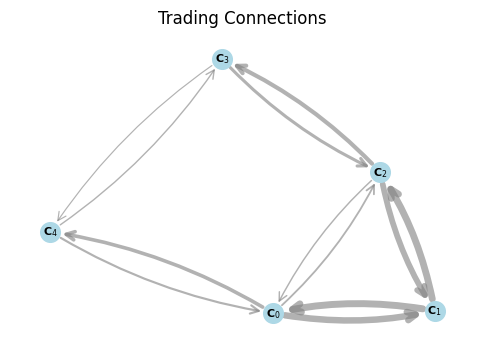

In [7]:
# visualization
G = nx.from_numpy_array(trading_p_nom_opt, create_using=nx.DiGraph)
plt.figure(figsize=(6, 4))
pos = nx.spring_layout(G, seed=10)  
weights = [G[u][v]['weight'] for u, v in G.edges()]
max_weight = max(weights) if weights else 1
norm_weights = [5 * (w / max_weight) for w in weights]
nx.draw_networkx_nodes(G, pos, node_size=200, node_color='lightblue')
nx.draw_networkx_edges(G, pos, width=norm_weights, arrowstyle='->', arrowsize=15,
                       edge_color='gray', alpha=0.6, connectionstyle='arc3,rad=0.1')
labels = {i: rf"C$_{i}$" for i in range(len(network.buses))}
nx.draw_networkx_labels(G, pos, labels, font_size=8, font_weight='bold')
plt.title("Trading Connections", fontsize=12)
plt.axis('off')
plt.show()

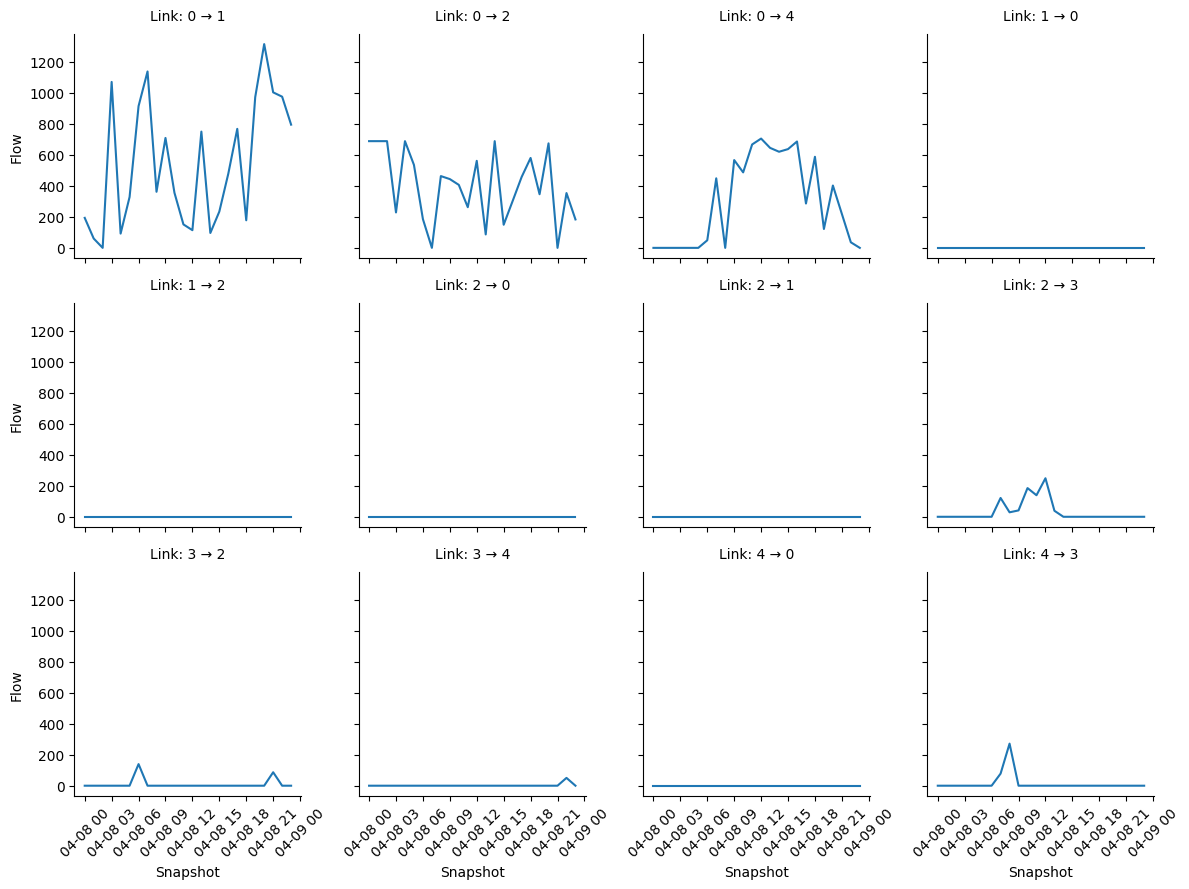

In [9]:
# trading between countries
plot_links(network, dates=dates, season='Spring', day=1)